# Yield Dataset EDA (Cleaned Data)

Exploratory analysis for the cleaned India agriculture yield regression dataset with the consolidated 4-season categories.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
ROOT = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
TRAIN_PATH = PROCESSED_DIR / 'yield_train_raw.csv'
TEST_PATH = PROCESSED_DIR / 'yield_test_raw.csv'
OUTPUTS_DIR = ROOT / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
df = pd.concat([train_df, test_df], ignore_index=True)

if 'Yield' not in df.columns and {'Production', 'Area'}.issubset(df.columns):
    df['Yield'] = np.where(df['Area'] > 0, df['Production'] / df['Area'], np.nan)

display(df.head())
print('Shape:', df.shape)
display(df['Season'].value_counts())
display(df.describe(include='all').T)
display((df.isna().mean() * 100).sort_values(ascending=False).to_frame('missing_pct'))

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Groundnut,2011,Kharif,Goa,357.0,1022.0,2698.2,59804.64,117.81,2.860000
1,Barley,2007,Kharif,Delhi,75.0,196.0,677.5,10005.00,12.00,2.610000
2,Moth,1999,Whole Year,Uttar Pradesh,204.0,84.0,883.4,21650.52,55.08,0.447273
3,Barley,2014,Rabi,Uttarakhand,21054.0,24800.0,1287.4,3178311.84,6947.82,1.170769
4,Cotton(lint),2002,Kharif,Madhya Pradesh,185695.0,304705.5,800.8,24727596.07,49569.20,0.535789


Shape: (19689, 10)


Season
Kharif        8646
Rabi          6131
Whole Year    3717
Summer        1195
Name: count, dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crop,19689,55,Rice,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,19689.0,NaN,NaN,NaN,2009.127584,6.498099,1997.0,2004.0,2010.0,2015.0,2020.0
Season,19689,4,Kharif,8646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,19689,30,Karnataka,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,19689.0,NaN,NaN,NaN,49091.86553,68864.272117,0.5,1390.0,9317.0,75112.0,185695.0
Production,19689.0,NaN,NaN,NaN,80716.405988,115591.715658,0.0,1393.0,13804.0,122718.0,304705.5
Annual_Rainfall,19689.0,NaN,NaN,NaN,1371.231397,614.694947,301.3,940.7,1247.6,1643.7,2698.2
Fertilizer,19689.0,NaN,NaN,NaN,6528930.835733,9148705.689865,54.17,188014.62,1234957.44,10003847.2,24727596.07
Pesticide,19689.0,NaN,NaN,NaN,13013.902888,18328.408492,0.09,356.7,2421.9,20041.7,49569.2
Yield,19689.0,NaN,NaN,NaN,1.783845,1.652179,0.0,0.6,1.03,2.388889,5.072222


,missing_pct
Crop,0.0
Crop_Year,0.0
Season,0.0
State,0.0
Area,0.0
Production,0.0
Annual_Rainfall,0.0
Fertilizer,0.0
Pesticide,0.0
Yield,0.0


## 1) Univariate Analysis

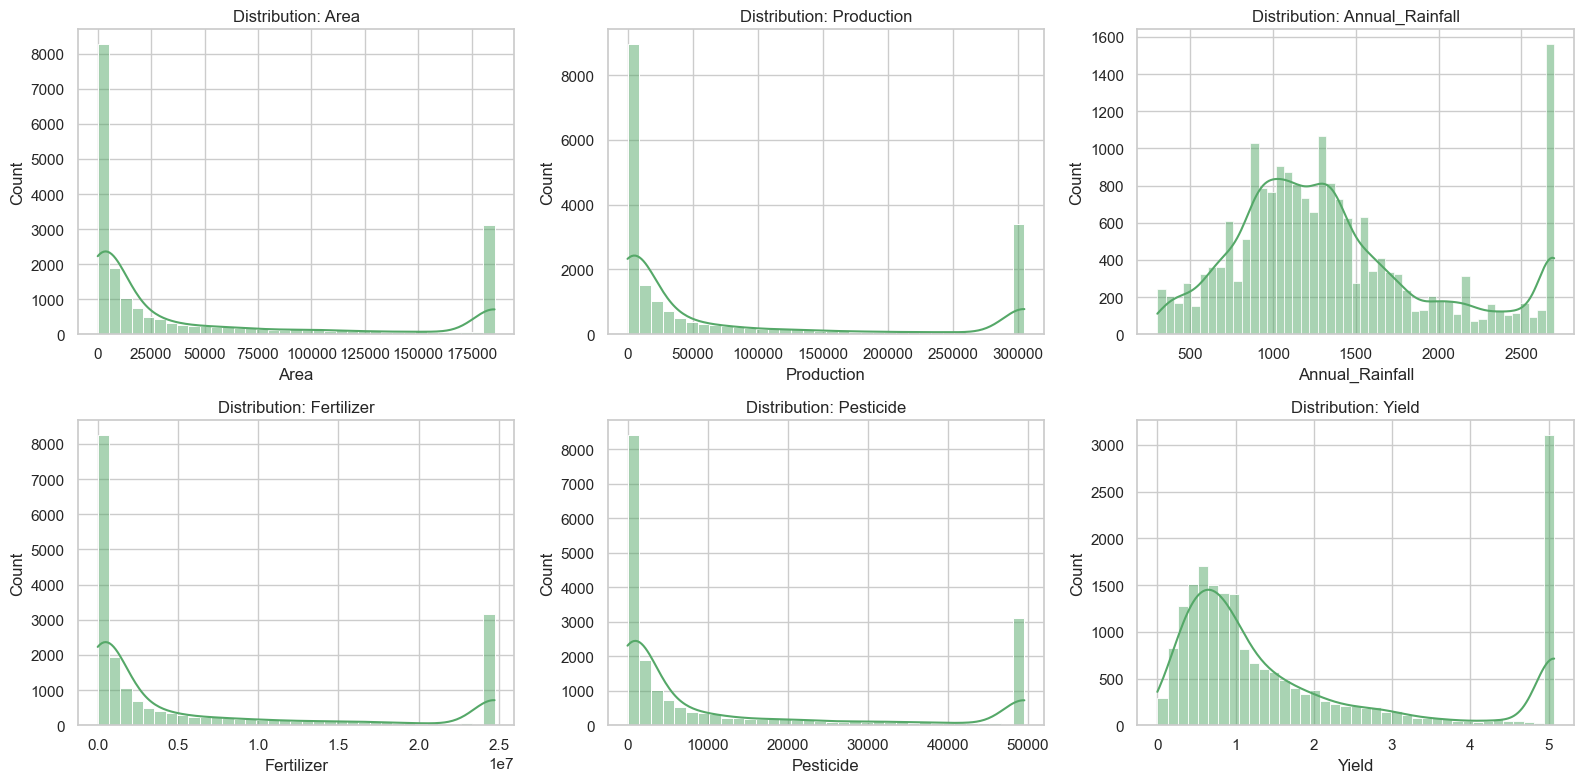

C:\Users\anshb\AppData\Local\Temp\ipykernel_19300\3667251854.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='mako')


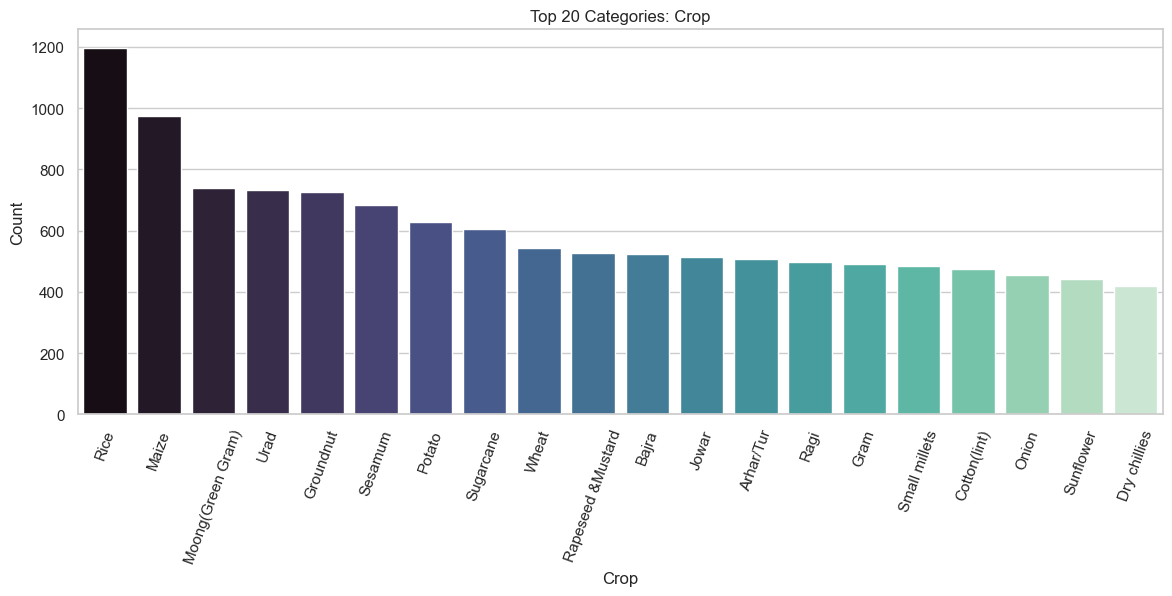

C:\Users\anshb\AppData\Local\Temp\ipykernel_19300\3667251854.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='mako')


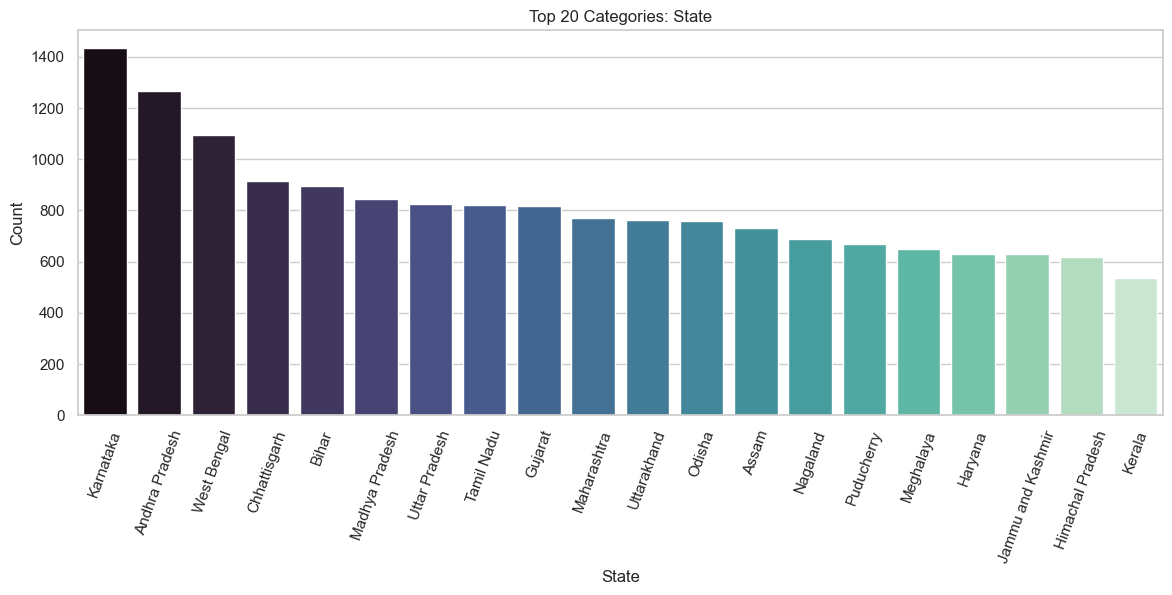

C:\Users\anshb\AppData\Local\Temp\ipykernel_19300\3667251854.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='mako')


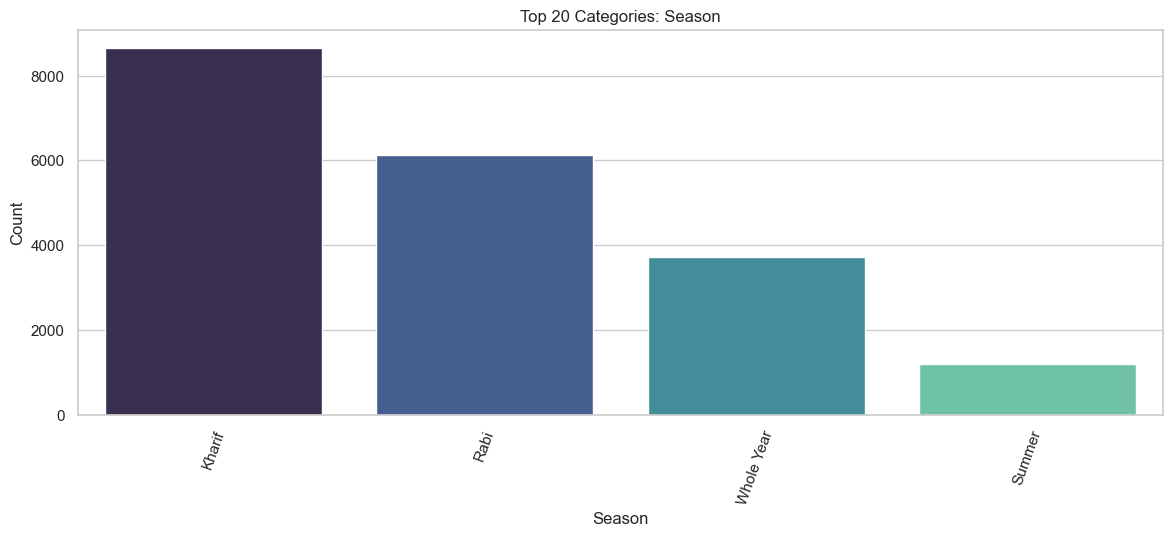

In [11]:
numeric_cols = [c for c in ['Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'] if c in df.columns]
cat_cols = [c for c in ['Crop', 'State', 'Season'] if c in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#55a868')
    axes[i].set_title(f'Distribution: {col}')
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

for col in cat_cols:
    plt.figure(figsize=(14, 5))
    counts = df[col].value_counts().head(20)
    sns.barplot(x=counts.index, y=counts.values, palette='mako')
    plt.title(f'Top 20 Categories: {col}')
    plt.xticks(rotation=70)
    plt.ylabel('Count')
    plt.show()

## 2) Bivariate and Multivariate Analysis

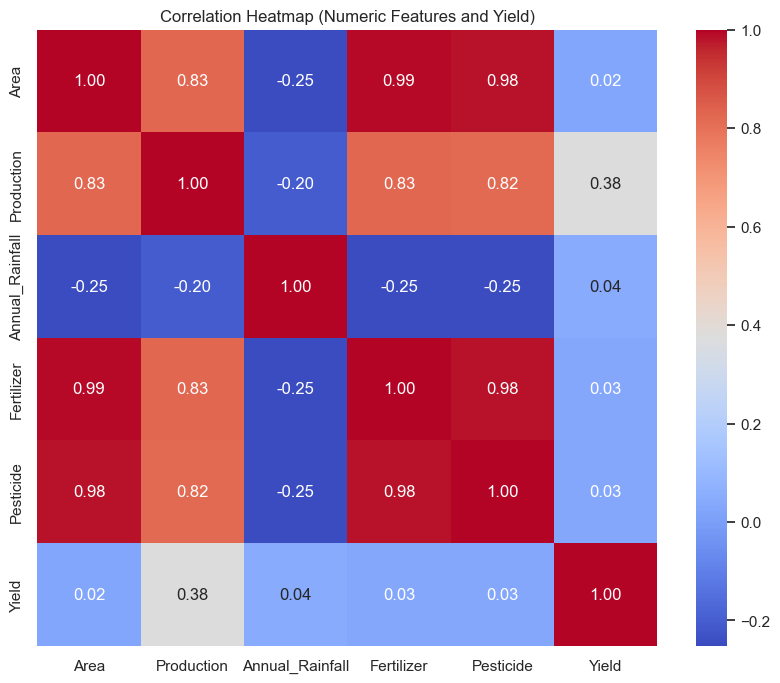

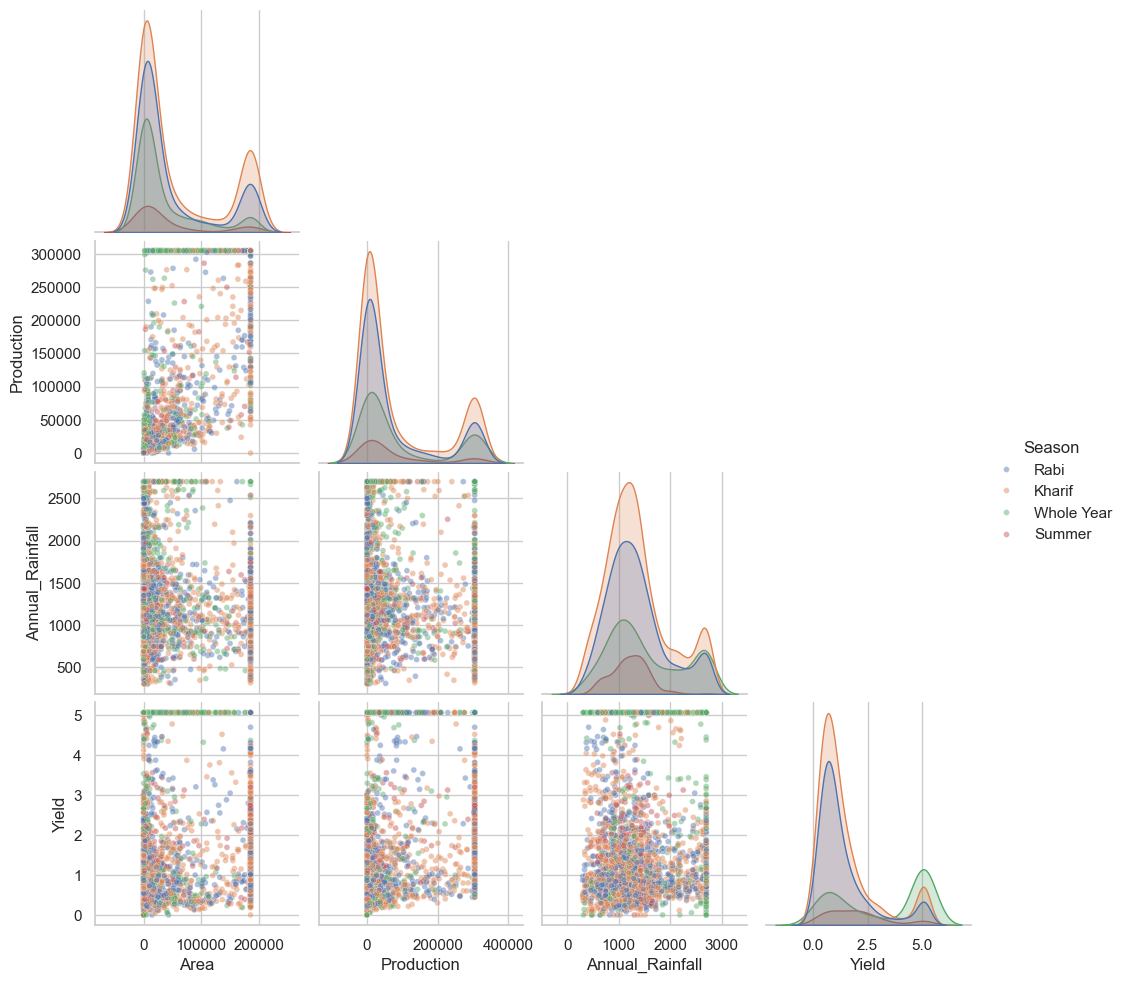

In [12]:
corr_cols = [c for c in numeric_cols if c in df.columns]
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features and Yield)')
plt.show()

pair_cols = [c for c in ['Area', 'Production', 'Annual_Rainfall', 'Yield'] if c in df.columns]
sample_df = df[pair_cols + (['Season'] if 'Season' in df.columns else [])].dropna().sample(min(3000, len(df)), random_state=RANDOM_STATE)
if 'Season' in sample_df.columns:
    sns.pairplot(sample_df, vars=pair_cols, hue='Season', corner=True, plot_kws={'alpha': 0.45, 's': 18})
else:
    sns.pairplot(sample_df, vars=pair_cols, corner=True, plot_kws={'alpha': 0.45, 's': 18})
plt.show()

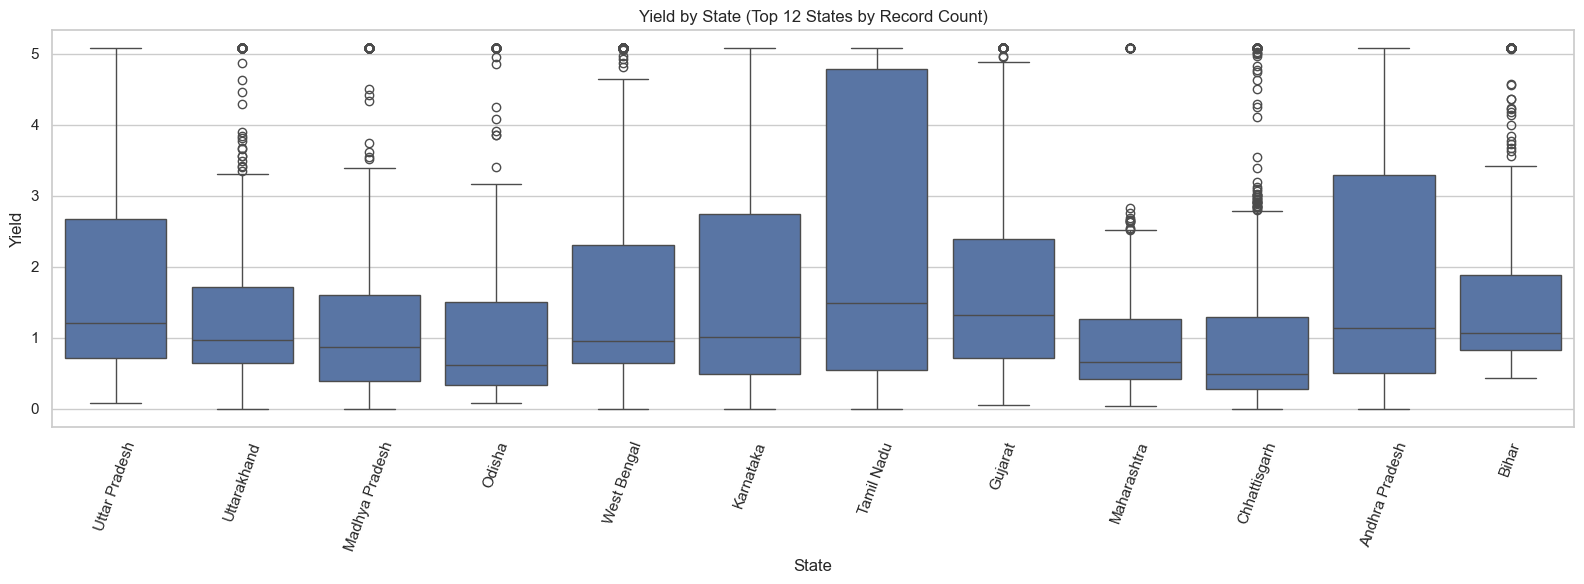

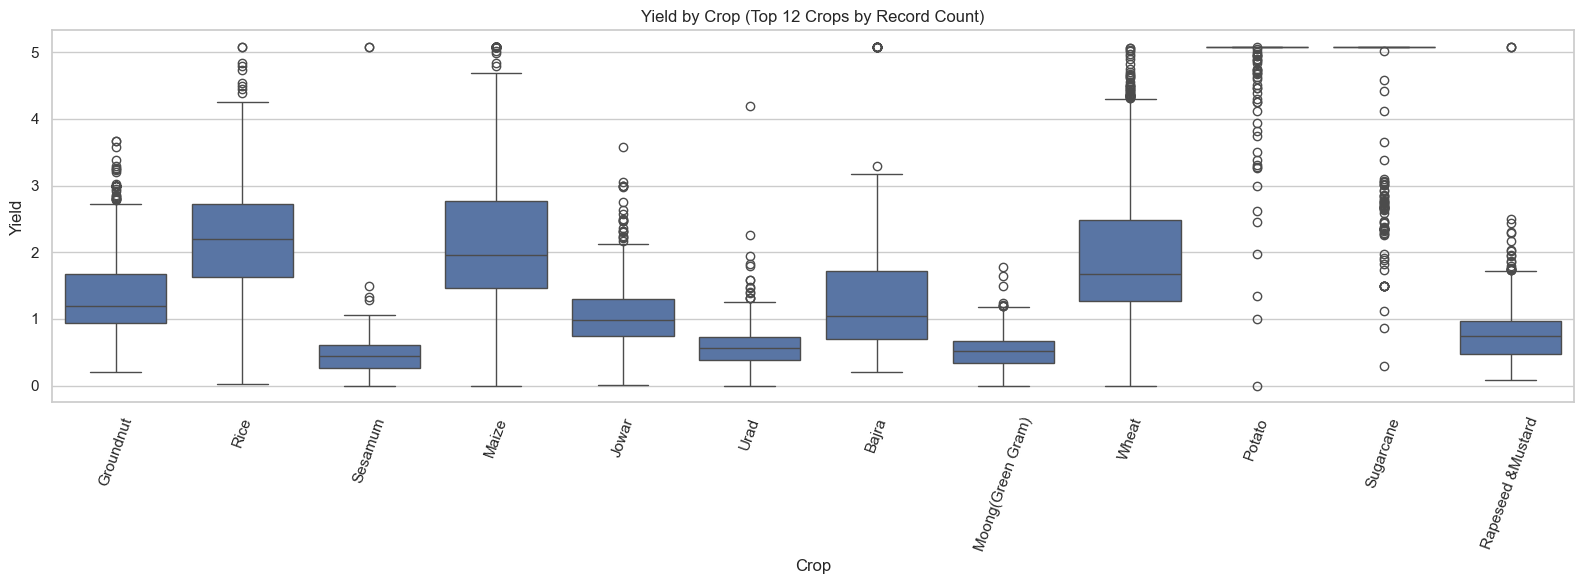

In [13]:
if 'State' in df.columns:
    top_states = df['State'].value_counts().head(12).index
    state_df = df[df['State'].isin(top_states)]
    plt.figure(figsize=(16, 6))
    sns.boxplot(data=state_df, x='State', y='Yield')
    plt.title('Yield by State (Top 12 States by Record Count)')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

if 'Crop' in df.columns:
    top_crops = df['Crop'].value_counts().head(12).index
    crop_df = df[df['Crop'].isin(top_crops)]
    plt.figure(figsize=(16, 6))
    sns.boxplot(data=crop_df, x='Crop', y='Yield')
    plt.title('Yield by Crop (Top 12 Crops by Record Count)')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

,importance
Production,0.274176
Area,0.194665
Season_Whole Year,0.150538
Crop_Potato,0.082835
Crop_Onion,0.037031
Fertilizer,0.028717
Crop_Tapioca,0.018738
Crop_Mesta,0.016946
Crop_Jute,0.016644
Crop_Sweet potato,0.016466


C:\Users\anshb\AppData\Local\Temp\ipykernel_19300\3762653312.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


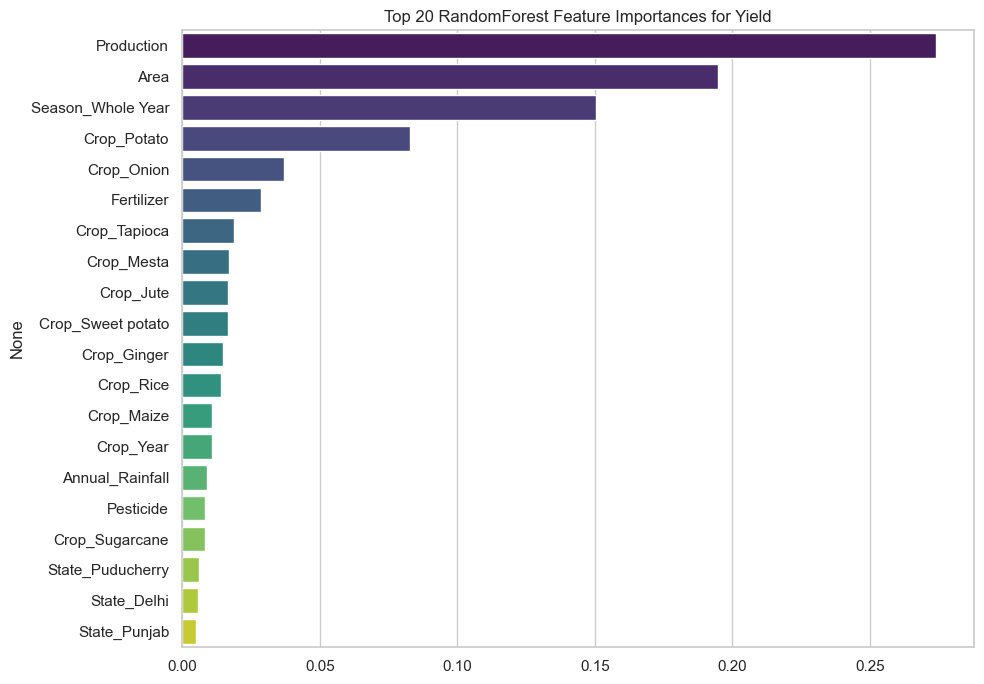

In [14]:
model_df = df.copy()
model_df = model_df.dropna(subset=['Yield'])
features = [c for c in model_df.columns if c != 'Yield']
X = pd.get_dummies(model_df[features], drop_first=False)
y = model_df['Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

rf = RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
display(importances.to_frame('importance'))

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 20 RandomForest Feature Importances for Yield')
plt.tight_layout()
plt.show()

importances.to_csv(OUTPUTS_DIR / 'yield_feature_importance_top20.csv')

## Key Insights Summary

- `Production`, `Area`, and climate-related features typically dominate correlation and feature-importance signals for yield.
- Boxplots indicate strong heterogeneity by state and crop type, supporting location- and crop-specific modeling.
- Heavy-tailed numeric distributions suggest robust preprocessing (outlier capping, transformations, and resilient models) is important.
- Correlation and pairwise structure can guide model family choice and feature engineering for robust regression performance.